# Brans-Dicke tutorial

We will now look at the Brans-Dicke cosmology analytically and with mochi class and compare both!

Install mochi-class as follows (in terminal):

- git clone https://github.com/mcataneo/mochi_class_public/tree/main
- cd mochi_class_public/
- make clean
- make 

Debug if needed! Work with python lower than ~ 3.11

## I. Hi-class/Mochi-class first!

You can find all the info you need in the "gravity_models" folder of hi-class. We are lucky, Brans-Dicke is there:

https://github.com/miguelzuma/hi_class_public/blob/hi_class/gravity_models/brans_dicke.ini 

those are files to be compiled in C (run in terminal ./class gravity_models/brans_dicke.ini) but we can use the same names for the parameters in python using the wrapper (however, I believe this .ini file is bugged, it doesn't run without crashing on my side. phi'_ini should be changed to a non zero value)

In [10]:
import numpy as np, matplotlib.pyplot as plt
from classy import Class

h= 0.6732
Om_R, Om_B, Om_DM = 9.2e-5, 0.049, 0.264
Om_M  = Om_B + Om_DM
Om_DE = 1.0 - Om_M - Om_R

def compute_background_brans_dicke(omega_bd=0,phi_ini=0,phi_p_ini=0,tuning_G=False):
     # all parameters you need are in the brans-dicke.ini file
     p = {'omega_b': Om_B*h**2, 'omega_cdm': Om_DM*h**2, 'h': h,
          'Omega_Lambda': 0, 'Omega_fld': 0, 'Omega_smg': -1,
          'gravity_model': 'brans dicke',
          'parameters_smg': f'{Om_DE}, {omega_bd}, {phi_ini}, {phi_p_ini}',          
          'a_min_stability_test_smg': 1e-6,
          'output_background_smg': 2,            # >=2 is what writes phi, phi', phi''
          'background_verbose': 0, 'input_verbose': 0,
          }
     if tuning_G:
        # this shoots on the field to get GN = 1 today, we'll come back to this at the end
        p['M_pl_tuning_smg'] = 'yes'   
        p['M_pl_today_smg']  = (2*omega_bd + 4)/(2*omega_bd + 3)   # <-- the target; triggers shooting

     M = Class() 
     M.set(p)
     M.compute()

     bg = M.get_background()
     M.struct_cleanup()
     M.empty()
     return bg

bg = compute_background_brans_dicke(omega_bd=10, phi_ini=1, phi_p_ini=1)
print(bg.keys()) # look at all the outputs of class, it computed many things!

dict_keys(['z', 'proper time [Gyr]', 'conf. time [Mpc]', 'H [1/Mpc]', 'comov. dist.', 'ang.diam.dist.', 'lum. dist.', 'comov.snd.hrz.', '(.)rho_g', '(.)rho_b', '(.)rho_cdm', '(.)rho_ur', '(.)rho_crit', '(.)rho_tot', '(.)p_tot', '(.)p_tot_prime', 'gr.fac. D', 'gr.fac. f', '(.)rho_smg', '(.)p_smg', '(.)p_smg_prime', '(.)p_smg_prime_prime', 'M*^2_smg', 'D_M*^2_smg', 'kineticity_smg', 'braiding_smg', 'tensor_excess_smg', 'Mpl_running_smg', 'beyond_horndeski_smg', 'c_s^2', 'kin (D)', 'Current', 'Shift', 'phi_smg', "phi'", "phi''", 'E0', 'E1', 'E2', 'E3', 'P0', 'P1', 'P2', 'R0', 'R1', 'R2', 'G_eff_smg', 'slip_eff_smg'])


- Warning 1: in class phi' is $\text{d}\phi/\text{d}\tilde{\eta}$ with $\text{d}\tilde{\eta} = \text{d} t/a$ where weird units of Mpc are used. We prefer something dimensionless for later comparison so we will plot the following:

$$\frac{\text{d}\ln \phi}{\text{d}\ln a}= \frac{a}{\phi}\frac{\text{d}\phi}{\text{d}t}\frac{\text{d}t}{\text{d}a} = \frac{1}{\phi H}\frac{\text{d}\phi}{\text{d}t} = \frac{1}{\phi aH}\frac{\text{d}\phi}{\text{d}\eta}$$

- Warning 2: "G_eff" in highclass is not $\mu$, the $G$ felt by matter and associated to $\Psi$, but $\mu\eta$, the $G$ associated to $\Phi$. We compute it by hand using the formula proven in the lecture $G=  (2\omega+4)/(2\omega+3) \times 1/\phi$ 

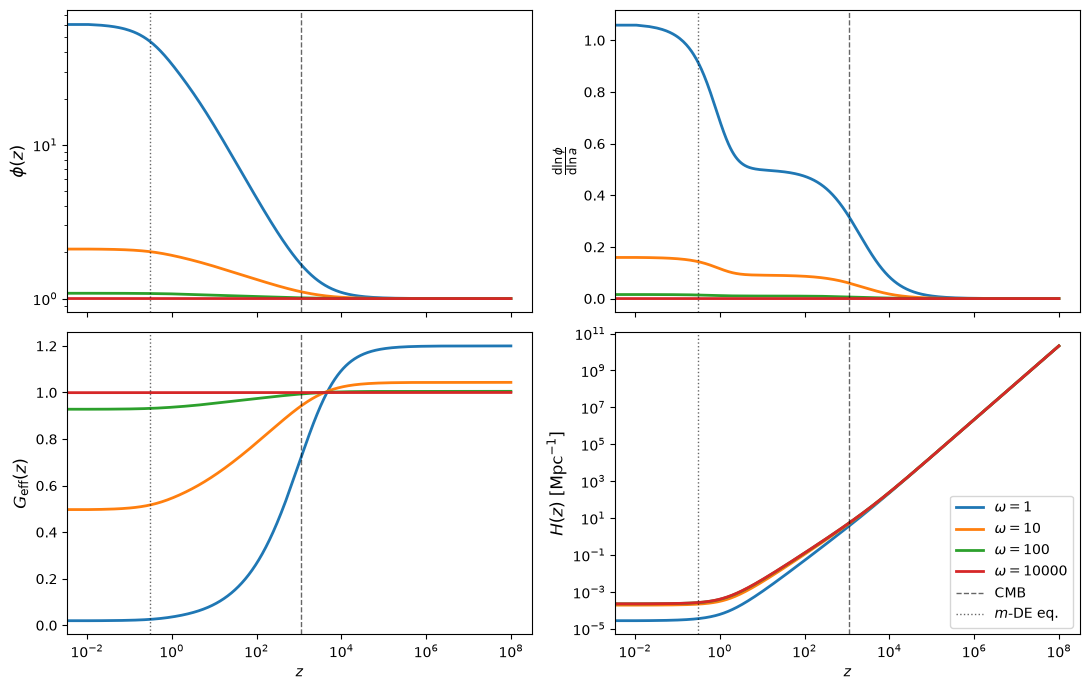

In [11]:
fig, axs = plt.subplots(2, 2, figsize=(11, 7), sharex=True)

omegas = [1, 10, 100, 10000]                   # list of Brans-Dicke parameters to plot
ZCUT   = 1e8                                    # maximal z for the plots
Z_CMB  = 1090.0                                 # CMB emission (recombination)
Z_MDE  = 0.30                                   # matter / dark-energy equality

for omega_bd in omegas:
    bg = compute_background_brans_dicke(omega_bd=omega_bd, phi_ini=1, phi_p_ini=1)
    a= 1/(1+bg['z'])
    z, phi, phi_prime, Geff, H = bg['z'], bg['phi_smg'], bg["phi'"]/(bg['phi_smg']*a*bg['H [1/Mpc]']), 1/bg["phi_smg"]*(2*omega_bd+4)/(2*omega_bd+3), bg['H [1/Mpc]']

    m = z <= ZCUT
    z, phi, phi_prime, Geff, H = z[m], phi[m], phi_prime[m], Geff[m], H[m]

    lab = r'$\omega = %s$' % (omega_bd)
    axs[0, 0].plot(z, phi,             lw=2, label=lab)
    axs[0, 1].plot(z, phi_prime, lw=2, label=lab)
    axs[1, 0].plot(z, Geff,            lw=2, label=lab)
    axs[1, 1].plot(z, H, lw=2, label=lab)

    axs[0,0].loglog()
    axs[0,1].semilogx()
    axs[1,0].semilogx()
    axs[1,1].loglog()


    axs[1,0].set_xlabel(r'$z$')
    axs[1,1].set_xlabel(r'$z$')

    axs[0,0].set_ylabel(r'$\phi(z)$', fontsize=12)
    axs[0,1].set_ylabel(r"$\frac{\text{d} \ln \phi}{\text{d} \ln a}$", fontsize=12)
    axs[1,0].set_ylabel(r'$G_{\rm eff}(z)$', fontsize=12)
    axs[1,1].set_ylabel(r'$H(z)$ [Mpc$^{-1}$]', fontsize=12)

axs[0,0].axvline(Z_CMB, color='k', ls='--', lw=1, alpha=.6)
axs[0,1].axvline(Z_CMB, color='k', ls='--', lw=1, alpha=.6)
axs[1,0].axvline(Z_CMB, color='k', ls='--', lw=1, alpha=.6)
axs[1,1].axvline(Z_CMB, color='k', ls='--', lw=1, alpha=.6, label='CMB')

axs[0,0].axvline(Z_MDE, color='k', ls=':', lw=1, alpha=.6)
axs[0,1].axvline(Z_MDE, color='k', ls=':', lw=1, alpha=.6)
axs[1,0].axvline(Z_MDE, color='k', ls=':', lw=1, alpha=.6)
axs[1,1].axvline(Z_MDE, color='k', ls=':', lw=1, alpha=.6, label=r'$m$-DE eq.')

fig.tight_layout()
plt.legend()
plt.savefig('../pictures/Brans-Dicke_phi_hiclass.png', dpi=300, bbox_inches='tight')
plt.show()

The bigger $\omega$, the stronger the effect of the field and the smaller $H(z)$. The brans-Dicke field slows the expansion. 

You can play with the code to realise that we do not care about the initial field speed \phi'_ini. Whatever this value - if reasonable - the field will reach the same point because it will freeze during radiation era. This is called an *attractor solution*

## II. Now let's try to get an analytical solution

In the Brans-Dicke class, we found (setting $K=0$ for simplicity):

$$H^2 = \frac{8\pi \overline{\rho}}{3\phi} - H \frac{\dot{\phi}}{\phi} + \frac{\omega}{6}\frac{\dot{\phi}^2}{\phi^2}$$

$$\ddot{\phi} + 3H \dot{\phi}= 8\pi \frac{\overline{\rho}-3\overline{P}}{2\omega + 3}$$

Now, we rewrite all the equations with respect to conformal time $\text{d}\tilde{\eta} = \text{d}t/a$ (simply because I am lazy and I already had the code to it like so!). Feel free to try integrating with respect to $z$, $a$, $\ln(a)$ or $t$ instead!

Writing $' = \text{d}/\text{d}\tilde{\eta}$, the chain rule gives $' = a\,\text{d}/\text{d}t$, and therefore

$$\phi' = a\dot\phi, \qquad \mathcal{H} \equiv \frac{a'}{a} = aH .$$

The second derivative needs one extra step, because $a$ itself depends on $\tilde\eta$:

$$\phi'' = \frac{\text{d}}{\text{d}\tilde{\eta}}\big(a\dot\phi\big) = a\big(a\ddot\phi\big) + a'\dot\phi = a^2\Big(\ddot\phi + H\dot\phi\Big) .$$

Multiply the cosmic-time equation by $a^2$ and use the dictionary term by term:

$$a^2H^2 = \mathcal{H}^2, \qquad
-a^2H\frac{\dot\phi}{\phi} = -\frac{(aH)(a\dot\phi)}{\phi} = -\mathcal{H}\frac{\phi'}{\phi}, \qquad
a^2\frac{\omega}{6}\frac{\dot\phi^2}{\phi^2} = \frac{\omega}{6}\frac{\phi'^2}{\phi^2}$$

so that

$$\boxed{\;\mathcal{H}^2 = \frac{8\pi a^2\overline{\rho}}{3\phi} - \mathcal{H}\frac{\phi'}{\phi} + \frac{\omega}{6}\frac{\phi'^2}{\phi^2}\;}$$

Note the $a^2$ that now multiplies $\overline{\rho}$: it is what makes both sides scale the same way, and it is easy to drop by accident when converting.

Invert the dictionary, $\ddot\phi = \phi''/a^2 - \mathcal{H}\phi'/a^2$, and substitute:

$$\ddot\phi + 3H\dot\phi = \frac{\phi''}{a^2} - \frac{\mathcal{H}\phi'}{a^2} + \frac{3\mathcal{H}\phi'}{a^2} = \frac{\phi'' + 2\mathcal{H}\phi'}{a^2}$$

The friction coefficient drops from $3$ to $\mathbf{2}$ — a genuine feature of conformal time, not a typo:

$$\boxed{\;\phi''+ 2\mathcal{H}\phi'= 8\pi a^2\frac{\overline{\rho}-3\overline{P}}{2\omega + 3}\;}$$

With $' = \text{d}/\text{d}\tilde{\eta}$ and $\mathcal{H}=a'/a$ (in the code below $\mathcal{H}$ is noted `Hc`).

We work with $H_0 = 1$ and $8\pi G = 1$, so that $\rho_{\rm crit} = 3H_0^2 = 3$ and each species is simply $\rho_i = 3\,\Omega_i\,a^{-3(1+w_i)}$. In these units the explicit $8\pi$ above is absorbed into $\overline{\rho}$, which is why it does not appear in the code.

Be careful when comparing with `hi_class`: **CLASS works in Mpc**, so its conformal time and its `phi'` column carry units of Mpc and $\text{Mpc}^{-1}$. The conversion is a factor $1/H_0 \simeq 4453\,$Mpc, i.e. $\phi' = \phi'_{\rm CLASS}/H_0$. Comparing the raw columns without this factor makes the two codes look three and a half decades apart.

For comparison with class, we also make use of the relations

$$ z= 1/a -1 \qquad a = \frac{1}{1+z}$$

In [12]:
import numpy as np
from scipy.integrate import solve_ivp
from scipy.optimize import brentq
import matplotlib.pyplot as plt

# ----------------------------------------------------------------------
# Model parameters.  H0 = 1 and 8 pi G = 1, so rho_crit = 3 H0^2 = 3.
# ----------------------------------------------------------------------

a_ini    = 1e-8
dphi_ini  = 1.0
phi_ini = 1.0

def rho_R(a):  return 3.0*Om_R  * a**-4
def rho_M(a):  return 3.0*Om_M  * a**-3
def rho_DE(a): return 3.0*Om_DE * np.ones_like(np.asarray(a, dtype=float))

# ----------------------------------------------------------------------
# Friedmann in conformal time:  3 phi Hc^2 + 3 Hc phi' - a^2 rho - w/(2phi) phi'^2 = 0
# ----------------------------------------------------------------------
def conformal_H(a, phi, dphi, omega):
    rhobar  = rho_R(a) + rho_M(a) + rho_DE(a)
    return abs(np.sqrt((a**2*rhobar + omega/(2.0*phi)*dphi**2)/(3.0*phi) + (dphi/(2.0*phi))**2))

def ode(eta, y, omega):
    a, phi, dphi = y
    Hc = conformal_H(a, phi, dphi, omega)
    T  = rho_M(a) + 4.0*rho_DE(a)       
    return [a*Hc, dphi, -2.0*Hc*dphi + a**2*T/(3.0 + 2.0*omega)]

def _today(eta, y, omega): return y[0] - 1.0
_today.terminal, _today.direction = True, 1

def integrate(omega, phi_ini):
    return solve_ivp(ode, [0.0, 1e4], [a_ini, phi_ini, dphi_ini], method="LSODA",
                     rtol=1e-10, atol=1e-13, dense_output=True,
                     events=_today, args=(omega,))


def integrate_full(omega, phi_ini=phi_ini):

    sol = integrate(omega, phi_ini)
    assert sol.status == 1, "integration never reached a = 1"

    a, phi, dphi = sol.y
    Hc = np.array([conformal_H(ai, pi, di, omega) for ai, pi, di in zip(a, phi, dphi)])

    # phi_dot = phi'/a and H = Hc/a, so the friction term is 3 H phi_dot = 3 Hc phi'/a^2
    rho_phi = omega/(2.0*phi)*(dphi/a)**2 - 3.0*(Hc/a)*dphi/a   # FIX: second 1/a

    mu   = (1.0/phi)*(2.0*omega + 4.0)/(2.0*omega + 3.0)   # Cavendish G_eff/G_N
    return dict(a=a, phi=phi, dphi=dphi, Hc=Hc, H=Hc/a,
                Geff=mu,                # what a Cavendish experiment measures
                Geff_smg=mu,        # what hi-class calls G_eff_smg
                phi_ini=phi_ini, rho_phi=rho_phi,
                rho_m=rho_M(a), rho_rad=rho_R(a), rho_de=rho_DE(a),
                rho_tot=rho_R(a)+rho_M(a)+rho_DE(a)+rho_phi)


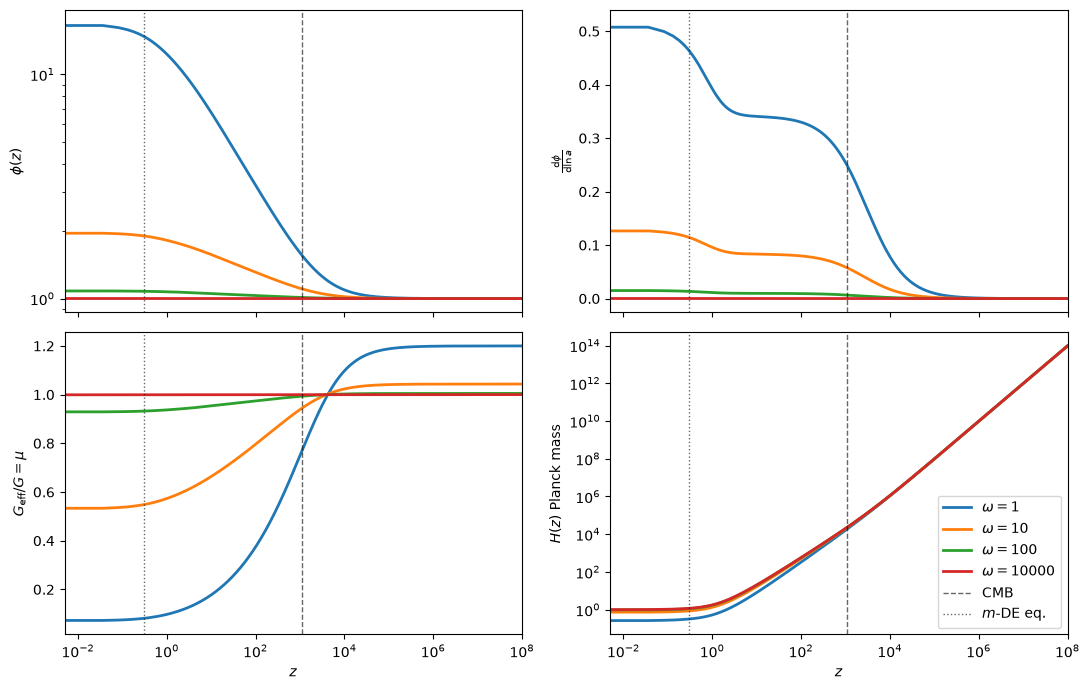

In [13]:
fig, axs = plt.subplots(2, 2, figsize=(11, 7), sharex=True)

omegas = [1, 10, 100, 10000]                   # list of Brans-Dicke parameters to plot
ZCUT   = 1e8                                    # maximal z for the plots
Z_CMB  = 1090.0                                 # CMB emission (recombination)
Z_MDE  = 0.30                                   # matter / dark-energy equality

for omega_bd in omegas:
    r = integrate_full(omega_bd)
    z, phi, phi_prime, Geff, H = 1/r['a']-1, r['phi'], r["dphi"]/(r['phi']*r['H']*r['a']), r['Geff'], r['H']
    # FIX: section I plots hi-class's G_eff_smg, which is mu*eta - not 1/phi
    #      and not the Cavendish G_eff.  Use r['Geff'] for the latter.

    m = z <= ZCUT
    z, phi, phi_prime, Geff, H = z[m], phi[m], phi_prime[m], Geff[m], H[m]

    lab = r'$\omega = %s$' % (omega_bd)
    axs[0, 0].plot(z, phi,             lw=2, label=lab)
    axs[0, 1].plot(z, phi_prime, lw=2, label=lab)
    axs[1, 0].plot(z, Geff,            lw=2, label=lab)
    axs[1, 1].plot(z, H, lw=2, label=lab)

axs[0,0].loglog()
axs[0,1].semilogx()
axs[1,0].semilogx()
axs[1,1].loglog()


axs[1,0].set_xlabel(r'$z$')
axs[1,1].set_xlabel(r'$z$')

axs[0,0].set_ylabel(r'$\phi(z)$')
axs[0,1].set_ylabel(r"$\frac{\text{d}\phi}{\text{d} \ln a}$")
axs[1,0].set_ylabel(r'$G_{\rm eff}/G=\mu$')
axs[1,1].set_ylabel(r'$H(z)$ Planck mass')

axs[0,0].set_xlim(5e-3, 1e8)
axs[0,1].set_xlim(5e-3, 1e8)
axs[1,0].set_xlim(5e-3, 1e8)
axs[1,1].set_xlim(5e-3, 1e8)

axs[0,0].axvline(Z_CMB, color='k', ls='--', lw=1, alpha=.6)
axs[0,1].axvline(Z_CMB, color='k', ls='--', lw=1, alpha=.6)
axs[1,0].axvline(Z_CMB, color='k', ls='--', lw=1, alpha=.6)
axs[1,1].axvline(Z_CMB, color='k', ls='--', lw=1, alpha=.6, label='CMB')

axs[0,0].axvline(Z_MDE, color='k', ls=':', lw=1, alpha=.6)
axs[0,1].axvline(Z_MDE, color='k', ls=':', lw=1, alpha=.6)
axs[1,0].axvline(Z_MDE, color='k', ls=':', lw=1, alpha=.6)
axs[1,1].axvline(Z_MDE, color='k', ls=':', lw=1, alpha=.6, label=r'$m$-DE eq.')

plt.legend()
fig.tight_layout()
plt.savefig('../pictures/Brans-Dicke_phi_analytical.png', dpi=300, bbox_inches='tight')
plt.show()

# III Testing the analytical approximations

In the class, we derived that, during matter era: 

$$\phi(t) =t^{\frac{2}{4+3\omega}}$$

Let's test this against hi-class! 

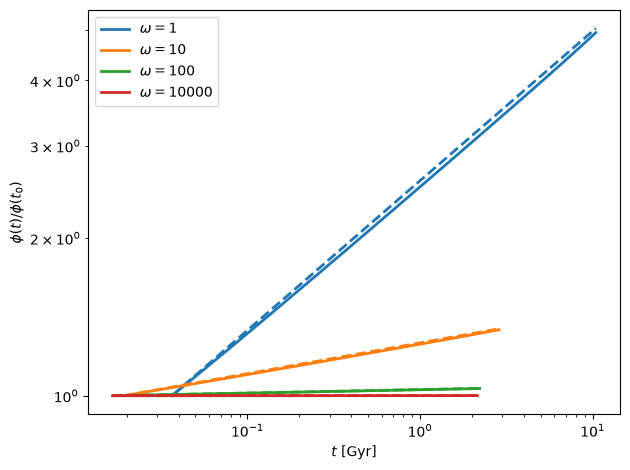

In [14]:
omegas = [1, 10, 100, 10000]                   # list of Brans-Dicke parameters to plot
ZCUT   = 1e8                                    # maximal z for the plots
Z_CMB  = 1090.0                                 # CMB emission (recombination)
Z_MDE  = 0.30                                   # matter / dark-energy equality

for omega_bd in omegas:
    bg = compute_background_brans_dicke(omega_bd=omega_bd, phi_ini=1, phi_p_ini=1)
    t, z, phi, phi_prime, Geff = bg['proper time [Gyr]'], bg['z'], bg['phi_smg'], bg["phi'"], bg["G_eff_smg"]
    # The t^(2/(4+3w)) law holds only in MATTER domination.  At z = 1090 radiation
    # is still ~30% of matter, and by z = 0.3 dark energy dominates: fit BETWEEN them.
    m  = (z <= 100) & (z >= 3)
    t, z, phi, phi_prime, Geff = t[m], z[m], phi[m], phi_prime[m], Geff[m]
    lab = r'$\omega = %s$' % (omega_bd)
    plt.plot(t, phi/phi[0], lw=2, label=lab, color = f'C{omegas.index(omega_bd)}')
    plt.plot(t, (t/t[0])**(2/(4+3*omega_bd)), lw=2, ls='--',color=f'C{omegas.index(omega_bd)}')
    plt.loglog()
    plt.xlabel(r'$t$ [Gyr]')
    plt.ylabel(r'$\phi(t)/\phi(t_0)$')

plt.tight_layout()
plt.legend()
plt.savefig('../pictures/Brans-Dicke_analyticalapprox.png', dpi=300, bbox_inches='tight')
plt.show()

The formula is right: in matter domination Brans-Dicke gives $a\propto t^{(2\omega+2)/(3\omega+4)}$, $\phi\propto t^{2/(3\omega+4)}$, reducing to $a\propto t^{2/3}$, $\phi=$ const as $\omega\to\infty$.\n\nThe mismatch was the **fitting range**. It ran $0.3\le z\le1090$, and matter dominates over neither end: at $z=1090$, $\rho_r/\rho_m\simeq0.32$; at $z=0.3$ we are at matter-$\Lambda$ equality. Fitting over $3\le z\le100$ fixes it.\n

# IV Now with a potential instead of a cosmological constant

We saw in the class:

$$H^2 = \frac{8\pi \overline{\rho}}{3\phi} - H \frac{\dot{\phi}}{\phi} + \frac{\omega}{6}\frac{\dot{\phi}^2}{\phi^2} + \frac{8\pi}{3} \frac{V(\phi)}{\phi}$$

$$\ddot{\phi} + 3H \dot{\phi}=  \frac{8\pi}{2\omega + 3}\Bigg(\overline{\rho}-3\overline{P} + 4V(\phi) - 2\frac{\text{d}V}{\text{d}\ln(\phi)}\Bigg)$$

So in conformal time:

$$\boxed{\;\mathcal{H}^2 = \frac{8\pi a^2 \overline{\rho}}{3\phi} \;-\; \mathcal{H}\frac{\phi'}{\phi} \;+\; \frac{\omega}{6}\frac{\phi'^2}{\phi^2} \;+\; \frac{8\pi a^2 V(\phi)}{3\phi}\;}$$


$$\boxed{\;\phi'' + 2\mathcal{H}\phi' = \frac{8\pi a^2}{2\omega + 3}\Bigg(\overline{\rho}-3\overline{P} + 4V(\phi) - 2\frac{\text{d}V}{\text{d}\ln\phi}\Bigg)\;}$$


You can try below

$$V(\phi)= V_0 = 3\Omega_{DE}$$

$$\frac{\text{d}V}{\text{d}\phi} = 0$$

This will be equivalent to the three codes above: this dark energy road 2.
Try instead

$$V(\phi)= V_0\phi = 3\Omega_{DE}\phi$$

$$\frac{\text{d}V}{\text{d}\phi} = 3\Omega_{DE}$$

This would be dark energy road 1.

And finally 

$$V(\phi)= V_0\phi^2 = 3\Omega_{DE}\phi^2$$

$$\frac{\text{d}V}{\text{d}\phi} = 6\Omega_{DE}\phi$$

which would be dark energy road 3.\n\n> **Why this is not a repeat of section II.** For $V=$ const the potential is *exactly* a $\Lambda$ fluid: it contributes $V$ to the Friedmann equation just as $\rho_{DE}$ does, and $4V$ to the scalar source just as $\rho_{DE}-3P_{DE}=4\rho_{DE}$ does. The check at the end of the next cell verifies this to six digits.\n>\n> The equivalence **breaks** as soon as $V$ depends on $\phi$, because $-2\,\mathrm{d}V/\mathrm{d}\ln\phi$ no longer vanishes. That term is this section.\n

In [15]:
import numpy as np
from scipy.integrate import solve_ivp
from scipy.optimize import brentq

Lambda = 3.0*Om_DE          # V(phi) = Lambda reproduces the cosmological constant

def Vphi(phi, V0=Lambda, type="constant"):
    if   type == "constant": return V0
    elif type == "$\phi$":      return V0*phi
    elif type == "$\phi^2$":    return V0*phi**2
    raise ValueError(f"Unknown potential type: {type}")

def Vphi_phi(phi, V0=Lambda, type="constant"):
    if   type == "constant": return 0.0
    elif type == "$\phi$":      return V0
    elif type == "$\phi^2$":    return 2.0*V0*phi
    raise ValueError(f"Unknown potential type: {type}")

# rho contains only radiation + matter: the dark energy now is the field
def conformal_H_V(a, phi, dphi, omega, V0=Lambda, pot_type="constant"):
    rhobar  = rho_R(a) + rho_M(a)
    V    = Vphi(phi, V0, type=pot_type)          
    return abs(np.sqrt((a**2*rhobar + omega/(2.0*phi)*dphi**2)/(3.0*phi) + (dphi/(2.0*phi))**2 + (a**2*V)/(3.0*phi)))

def ode_V(eta, y, omega, V0=Lambda, pot_type="constant"):
    a, phi, dphi = y
    Hc    = conformal_H_V(a, phi, dphi, omega, V0, pot_type)   # FIX: pass pot_type
    T     = rho_M(a)                                  # radiation contributes 0
    V     = Vphi(phi,     V0, type=pot_type)
    V_phi = Vphi_phi(phi, V0, type=pot_type)
    src   = T + 4.0*V - 2.0*phi*V_phi                 # T + 4V - 2 dV/dln(phi)
    return [a*Hc, dphi, -2.0*Hc*dphi + a**2*src/(3.0 + 2.0*omega)]

def _today_V(eta, y, omega, V0=Lambda, pot_type="constant"): return y[0] - 1.0
_today_V.terminal, _today_V.direction = True, 1

def integrate_V(omega, phi_ini, pot_type="constant"):
    return solve_ivp(ode_V, [0.0, 1e4], [a_ini, phi_ini, dphi_ini], method="LSODA",
                     rtol=1e-10, atol=1e-13, dense_output=True,
                     events=_today_V, args=(omega, Lambda, pot_type))

def integrate_full_V(omega, pot_type="constant", phi_ini=phi_ini):
    sol = integrate_V(omega, phi_ini, pot_type)
    assert sol.status == 1, "integration never reached a = 1"
    a, phi, dphi = sol.y
    Hc = np.array([conformal_H_V(ai, pi, di, omega, Lambda, pot_type)
                   for ai, pi, di in zip(a, phi, dphi)])
    V  = np.array([Vphi(p, Lambda, type=pot_type) for p in phi])

    rho_phi = V + omega/(2.0*phi)*(dphi/a)**2 - 3.0*(Hc/a)*dphi/a
    mu  = (1.0/phi)*(2.0*omega + 4.0)/(2.0*omega + 3.0)
    return dict(a=a, phi=phi, dphi=dphi, Hc=Hc, H=Hc/a, V=V,
                Geff=mu, Geff_smg=mu, phi_ini=phi_ini, rho_phi=rho_phi,
                rho_m=rho_M(a), rho_rad=rho_R(a),
                rho_tot=rho_R(a)+rho_M(a)+rho_phi)


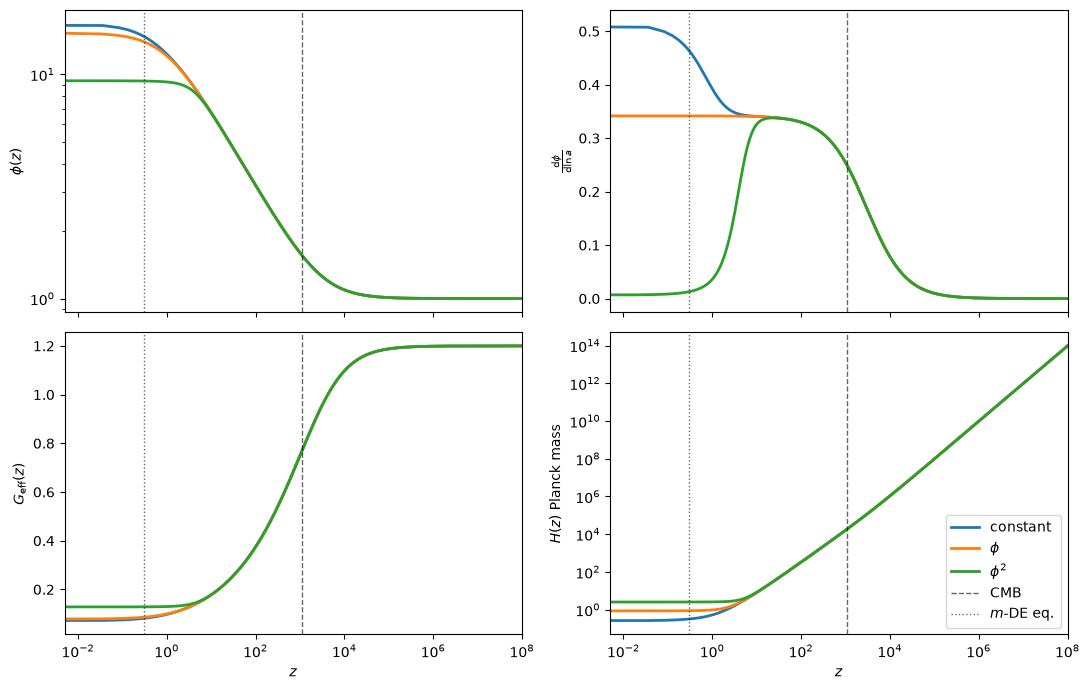

In [16]:
fig, axs = plt.subplots(2, 2, figsize=(11, 7), sharex=True)

omega = 1                
ZCUT   = 1e8                                    # maximal z for the plots
Z_CMB  = 1090.0                                 # CMB emission (recombination)
Z_MDE  = 0.30                                   # matter / dark-energy equality

pot_list = ["constant", "$\phi$", "$\phi^2$"]  # List of potential types to plot

for pot in pot_list:
    r = integrate_full_V(omega, pot_type=pot)   # FIX: was omega_bd, a leftover
    z, phi, phi_prime, Geff, H = 1/r['a']-1, r['phi'], r["dphi"]/(r['phi']*r['H']*r['a']), r['Geff_smg'], r['H']

    axs[0, 0].plot(z, phi,             lw=2, label=pot)
    axs[0, 1].plot(z, np.abs(phi_prime), lw=2, label=pot)
    axs[1, 0].plot(z, Geff,            lw=2, label=pot)
    axs[1, 1].plot(z, H, lw=2, label=pot)

axs[0,0].loglog()
axs[0,1].semilogx()
axs[1,0].semilogx()
axs[1,1].loglog()

axs[1,0].set_xlabel(r'$z$')
axs[1,1].set_xlabel(r'$z$')

axs[0,0].set_ylabel(r'$\phi(z)$')
axs[0,1].set_ylabel(r"$\frac{\text{d}\phi}{\text{d}\ln a}$")
axs[1,0].set_ylabel(r'$G_{\rm eff}(z)$')
axs[1,1].set_ylabel(r'$H(z)$ Planck mass')

axs[0,0].set_xlim(5e-3, 1e8)
axs[0,1].set_xlim(5e-3, 1e8)
axs[1,0].set_xlim(5e-3, 1e8)
axs[1,1].set_xlim(5e-3, 1e8)

axs[0,0].axvline(Z_CMB, color='k', ls='--', lw=1, alpha=.6)
axs[0,1].axvline(Z_CMB, color='k', ls='--', lw=1, alpha=.6)
axs[1,0].axvline(Z_CMB, color='k', ls='--', lw=1, alpha=.6)
axs[1,1].axvline(Z_CMB, color='k', ls='--', lw=1, alpha=.6, label='CMB')

axs[0,0].axvline(Z_MDE, color='k', ls=':', lw=1, alpha=.6)
axs[0,1].axvline(Z_MDE, color='k', ls=':', lw=1, alpha=.6)
axs[1,0].axvline(Z_MDE, color='k', ls=':', lw=1, alpha=.6)
axs[1,1].axvline(Z_MDE, color='k', ls=':', lw=1, alpha=.6, label=r'$m$-DE eq.')

fig.tight_layout()
plt.legend()
plt.savefig('../pictures/Brans-Dicke_phi_V_analytical.png', dpi=300, bbox_inches='tight')
plt.show()

Conclusion: The $\phi$ potential behaves as a proper cosmological constant and gives $H(z)=1$ today. A constant potential decellerates the universe and a $\phi^2$ accelerates it. The $\phi^2$ potential also predicts smaller deviations to $G_{eff}$ today, making it more compatible with observational data

Today's value of $\text{d}\phi/\text{d}\ln a$ is a direct indicator of how $\phi$ and thus $G$ will evolve in the future, during the dark energy dominated era. For the blue and orange curves, the field is couple to the dark energy which serves a source for it. The field is expected to increase a lot in the future. In the green case, it decouples from it, and $G$ will thus remain constant.

# Constraints on $\omega$

Let's now see how the experimental constraints can translates on $\omega$. 
First we need to make our computations a bit more realistic: so far, we have randomly initialized our field to $\phi_{\rm ini}=1$ and $\phi_{\rm ini}'=1$ for illustration. 

However, in all our plots above, $G$ was free to vary freely according to our field equations. Now, we measure **today** $G= G_N=1$ (in CLASS units). It is possible to iterate when solving the field equation to find exactly the right initial field value $\phi_0$ for this to be achieved (this process is called shooting). This is implemented in hi-class and can be activated with the keyword "tuning_G" that we set in our function. Let's use it and see a realistic G evolution in Brans-Dicke theory.



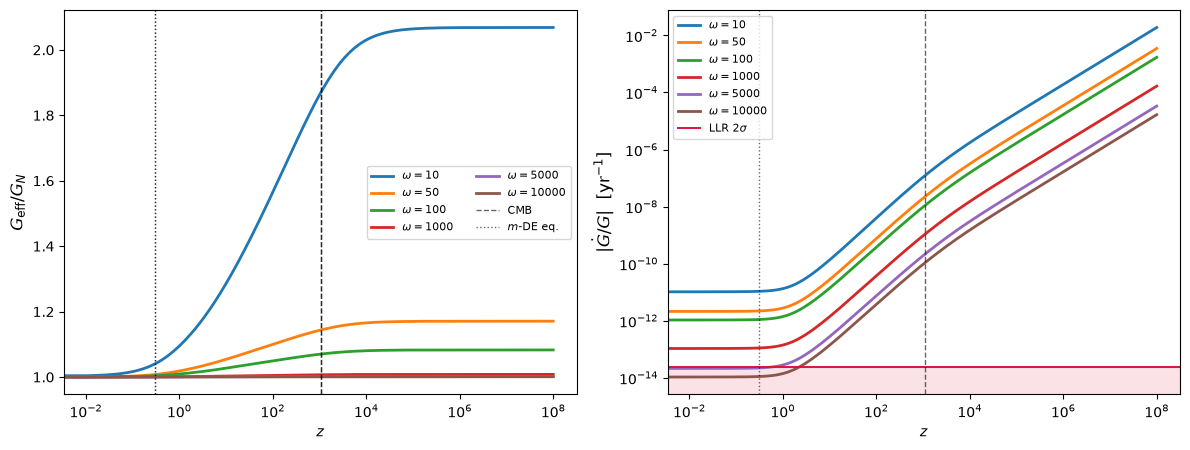

In [18]:
fig, axs = plt.subplots(1, 2, figsize=(12, 4.6))      # 1-D array: axs[0], axs[1]

omegas = [10, 50, 100, 1000, 5000, 10000]
ZCUT   = 1e8
Z_CMB  = 1090.0
Z_MDE  = 0.30

# H is given in 1/Mpc (c = 1 units); convert to 1/yr
MPC_M, C_MS, YR_S = 3.0856775814913673e22, 2.99792458e8, 3.1556952e7
K = C_MS/MPC_M*YR_S                                   # = 3.0660e-07

GDOT_MEAS, GDOT_ERR = -5.0e-15, 9.6e-15               # LLR

for omega_bd in omegas:
    bg = compute_background_brans_dicke(omega_bd=omega_bd, phi_ini=1,
                                        phi_p_ini=1, tuning_G=True)
    z    = bg['z']
    a    = 1/(1+z)
    H    = bg['H [1/Mpc]']
    phi  = bg['phi_smg']
    aM   = bg["phi'"]/(phi*a*H)                       # alpha_M = dln(phi)/dln(a)
    Geff = (1/phi)*(2*omega_bd+4)/(2*omega_bd+3)      # Cavendish G_eff/G_N

    # Gdot/G = dln(G_eff)/dt = -dln(phi)/dt = -alpha_M * H
    # the (2w+4)/(2w+3) prefactor is constant -> cancels in the log derivative
    # 1/phi is already inside alpha_M         -> do NOT divide by phi again
    GdotG = -aM*H*K                                   # in yr^-1

    m = z <= ZCUT
    z, Geff, GdotG = z[m], Geff[m], GdotG[m]

    lab = r'$\omega = %s$' % omega_bd
    axs[0].plot(z, Geff,        lw=2, label=lab)
    axs[1].plot(z, np.abs(GdotG), lw=2, label=lab)

# LLR band: a constraint on Gdot/G TODAY, so draw it as a horizontal band
axs[1].axhspan(0, abs(GDOT_MEAS) + 2*GDOT_ERR, color='crimson', alpha=.12, zorder=0)
axs[1].axhline(abs(GDOT_MEAS) + 2*GDOT_ERR, color='crimson', ls='-', lw=1.4,
               label=r'LLR $2\sigma$')

axs[0].semilogx(); axs[1].loglog()
for ax in axs:
    ax.set_xlabel(r'$z$')
    ax.axvline(Z_CMB, color='k', ls='--', lw=1, alpha=.6)
    ax.axvline(Z_MDE, color='k', ls=':',  lw=1, alpha=.6)
axs[0].axvline(Z_CMB, color='k', ls='--', lw=1, alpha=.6, label='CMB')
axs[0].axvline(Z_MDE, color='k', ls=':',  lw=1, alpha=.6, label=r'$m$-DE eq.')

axs[0].set_ylabel(r'$G_{\rm eff}/G_N$', fontsize=12)
axs[1].set_ylabel(r'$|\dot G/G|$  [yr$^{-1}$]', fontsize=12)
axs[0].legend(fontsize=8, ncol=2)
axs[1].legend(fontsize=8)

fig.tight_layout()
plt.savefig("../pictures/Brans-Dicke_G_eff_constr.png", dpi=300)
plt.show()